In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns



In [31]:
# ── 1. Load data and standardize column names ────────────────────
df = pd.read_csv("../data/raw/train.csv")

# Rename columns to remove spaces and standardize naming
column_mapping = {
    'Overall Qual': 'OverallQual',
    'Gr Liv Area': 'GrLivArea',
    'Year Built': 'YearBuilt',
    'Total Bsmt SF': 'TotalBsmtSF',
    'Garage Cars': 'GarageCars',
    'Full Bath': 'FullBath',
    'Lot Area': 'LotArea',
    'Bedroom AbvGr': 'BedroomAbvGr',
    'House Style': 'HouseStyle',
    'Yr Sold': 'YrSold'
}
df = df.rename(columns=column_mapping)

# Create House Age feature
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

SELECTED_FEATURES = [
    'OverallQual',
    'GrLivArea',
    'Neighborhood',
    'TotalBsmtSF',
    'GarageCars',
    'FullBath',
    'LotArea',
    'BedroomAbvGr',
    'HouseStyle',
    'HouseAge'
]

TARGET = "SalePrice"
df = df[SELECTED_FEATURES + [TARGET]].copy()

print("Shape after renaming and feature selection:", df.shape)
df.head()

Shape after renaming and feature selection: (2930, 11)


,OverallQual,GrLivArea,Neighborhood,TotalBsmtSF,GarageCars,FullBath,LotArea,BedroomAbvGr,HouseStyle,HouseAge,SalePrice
0,6,1656,NAmes,1080.0,2.0,1,31770,3,1Story,50,215000
1,5,896,NAmes,882.0,1.0,1,11622,2,1Story,49,105000
2,6,1329,NAmes,1329.0,1.0,1,14267,3,1Story,52,172000
3,7,2110,NAmes,2110.0,2.0,2,11160,3,1Story,42,244000
4,5,1629,Gilbert,928.0,2.0,2,13830,3,2Story,13,189900


In [32]:
# ── 2. Identify and remove outliers ────────────────────────────────
# Outlier: houses with large living area but low price (data error)
outlier_condition = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)
print(f"Found {outlier_condition.sum()} outliers to remove")
print(df[outlier_condition][["GrLivArea", "OverallQual", "Neighborhood", "SalePrice"]])

Found 3 outliers to remove
      GrLivArea  OverallQual Neighborhood  SalePrice
1498       5642           10      Edwards     160000
2180       5095           10      Edwards     183850
2181       4676           10      Edwards     184750


In [33]:
# Remove outliers
df = df[~outlier_condition].reset_index(drop=True)
print(f"Shape after removing outliers: {df.shape}")

Shape after removing outliers: (2927, 11)


In [34]:
# ── 3. Split data into train (60%), validation (20%), test (20%) ────
# Do this BEFORE handling missing values to avoid data leakage
# Step 1: Split 60% train, 40% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    random_state=42
)

# Step 2: Split the 40% temp evenly -> 20% val, 20% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

total_rows = len(df)
print(f"Train: {len(train_df):4d} rows ({len(train_df)/total_rows*100:.1f}%)")
print(f"Val:   {len(val_df):4d} rows ({len(val_df)/total_rows*100:.1f}%)")
print(f"Test:  {len(test_df):4d} rows ({len(test_df)/total_rows*100:.1f}%)")
print(f"Total: {total_rows:4d} rows")

Train: 1756 rows (60.0%)
Val:    585 rows (20.0%)
Test:   586 rows (20.0%)
Total: 2927 rows


In [35]:
# ── 3b. Check for duplicates BEFORE splitting ────────────────────
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 3
Shape after removing duplicates: (2924, 11)


In [36]:
# ── 5. Define feature groups for analysis and preprocessing ────────
NUMERIC_FEATURES = [
    'OverallQual',
    'GrLivArea',
    'HouseAge',
    'TotalBsmtSF',
    'GarageCars',
    'FullBath',
    'LotArea',
    'BedroomAbvGr'
]

CATEGORICAL_FEATURES = [
    'Neighborhood',
    'HouseStyle'
]

LOG_FEATURES = [
    'GrLivArea',
    'TotalBsmtSF',
    'LotArea'
]

PLAIN_NUMERIC_FEATURES = [
    col for col in NUMERIC_FEATURES if col not in LOG_FEATURES
]

print("Numeric features (total):", len(NUMERIC_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))
print("Features requiring log transform:", LOG_FEATURES)

Numeric features (total): 8
Categorical features: 2
Features requiring log transform: ['GrLivArea', 'TotalBsmtSF', 'LotArea']


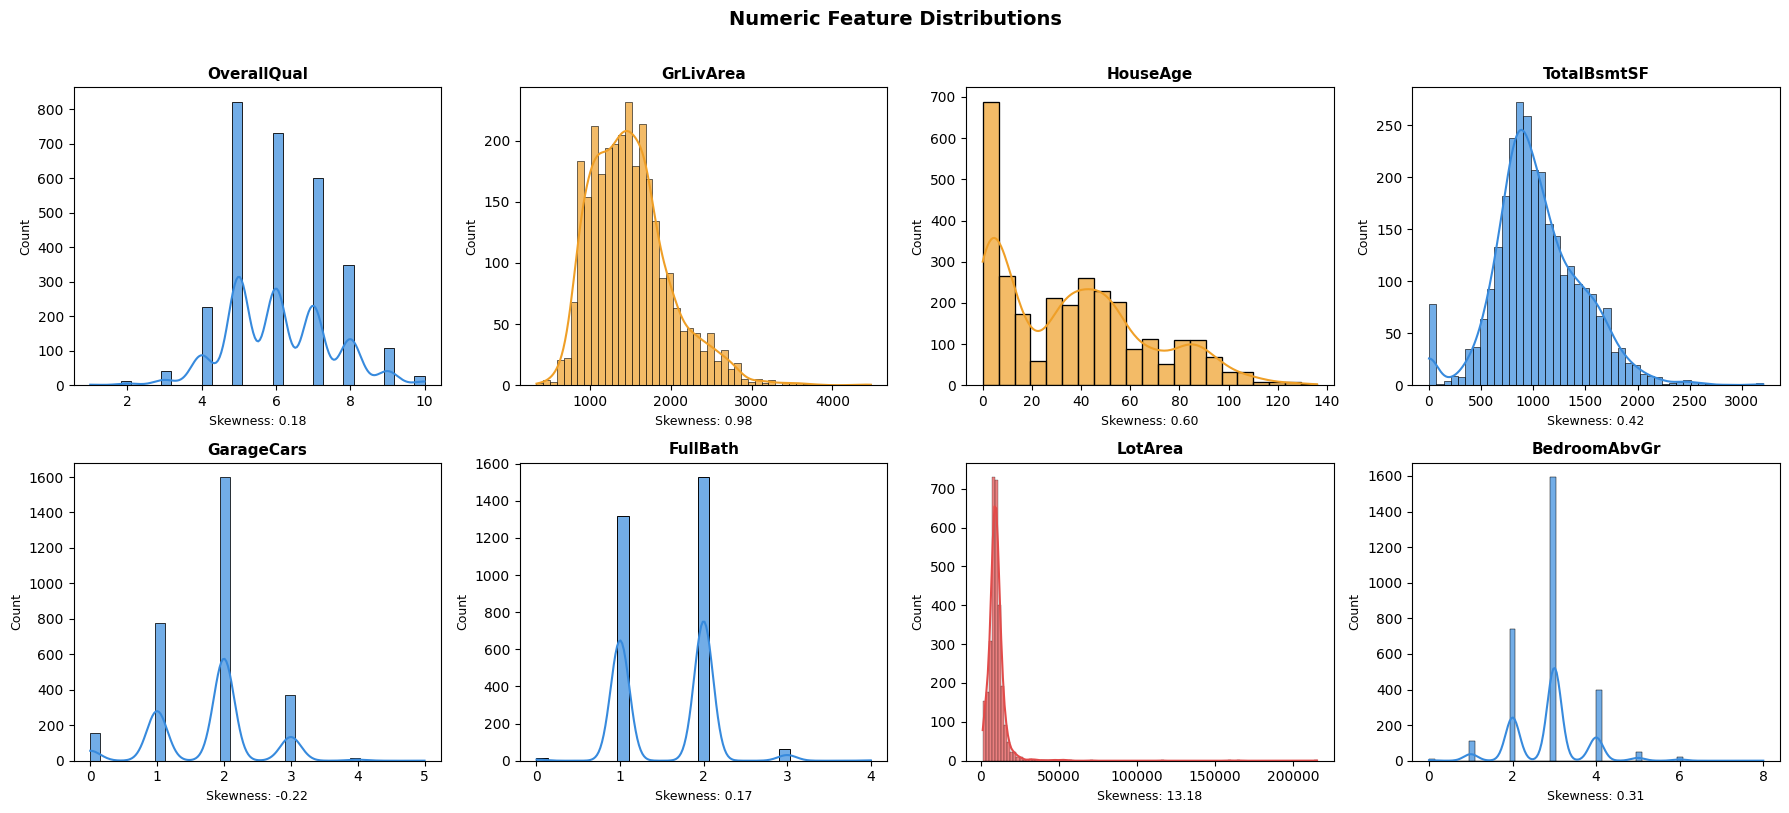

In [37]:
# ── 2. Plot numeric features ───────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    skewness = df[col].skew()

    if abs(skewness) < 0.5:
        color = '#378ADD'
    elif abs(skewness) < 1.0:
        color = '#EF9F27'
    else:
        color = '#E24B4A'

    sns.histplot(df[col], kde=True, ax=ax, color=color, alpha=0.7)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Skewness: {skewness:.2f}', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

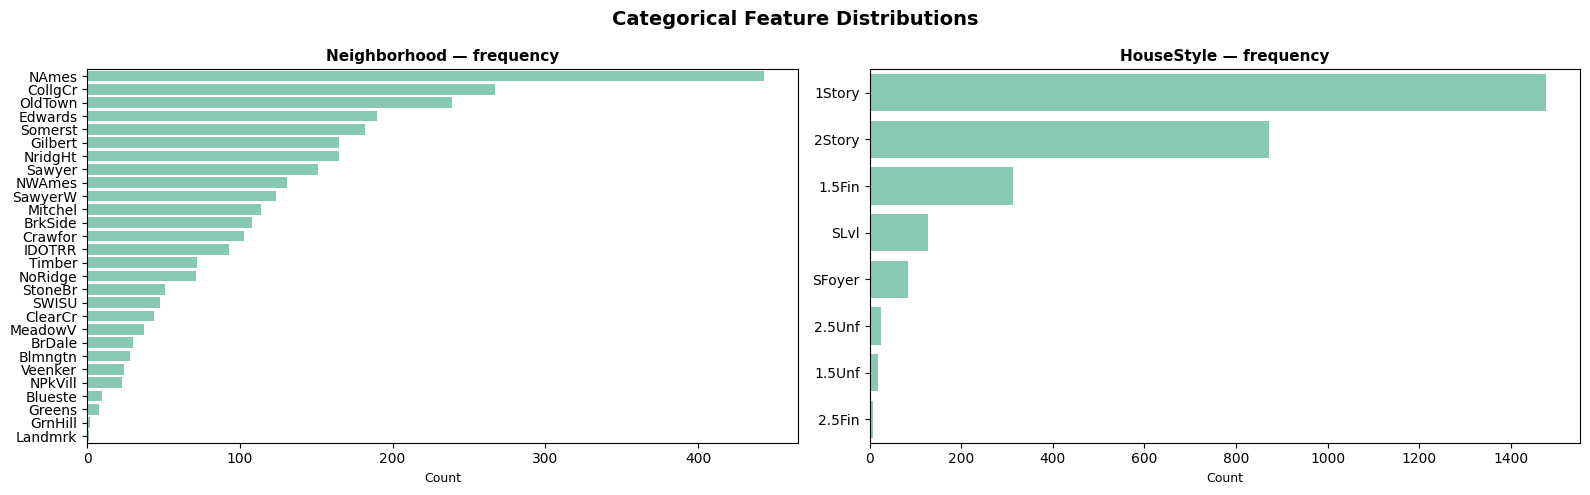

In [38]:
# ── 3. Plot categorical features ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(CATEGORICAL_FEATURES):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color='#5DCAA5', alpha=0.8)
    ax.set_title(f'{col} — frequency', fontsize=11, fontweight='bold')
    ax.set_xlabel('Count', fontsize=9)
    ax.set_ylabel('')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# ── 4. Skewness summary table ──────────────────────────────────────
skew_df = pd.DataFrame({
    'Feature': NUMERIC_FEATURES,
    'Skewness': [df[col].skew() for col in NUMERIC_FEATURES]
}).sort_values('Skewness', key=abs, ascending=False)

def flag(s):
    if abs(s) < 0.5:  return '✅ approx. normal'
    if abs(s) < 1.0:  return '⚠️  moderate skew'
    return '🔴 high skew — consider log transform'

skew_df['Status'] = skew_df['Skewness'].apply(flag)
print(skew_df.to_string(index=False))

     Feature  Skewness                               Status
     LotArea 13.182358 🔴 high skew — consider log transform
   GrLivArea  0.975943                    ⚠️  moderate skew
    HouseAge  0.601365                    ⚠️  moderate skew
 TotalBsmtSF  0.416848                     ✅ approx. normal
BedroomAbvGr  0.305713                     ✅ approx. normal
  GarageCars -0.217609                     ✅ approx. normal
 OverallQual  0.178826                     ✅ approx. normal
    FullBath  0.169090                     ✅ approx. normal


In [40]:
# ── 4. Handle missing values SEPARATELY on each split ───────────────
# This prevents data leakage: imputation statistics come from train only

print("\n📊 MISSING VALUE ANALYSIS:")
print("=" * 60)

# Check for missing values in each split
for split_name, split_data in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    missing = split_data[SELECTED_FEATURES + [TARGET]].isnull().sum()
    if missing.sum() > 0:
        print(f"\n{split_name} - Missing values:")
        print(missing[missing > 0])
    else:
        print(f"\n{split_name} - No missing values ✅")



📊 MISSING VALUE ANALYSIS:

Train - Missing values:
TotalBsmtSF    1
dtype: int64

Val - No missing values ✅

Test - Missing values:
GarageCars    1
dtype: int64


In [41]:
# ── 7. Save processed splits ───────────────────────────────────────
import os
os.makedirs("../data/processed", exist_ok=True)

train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

print("✅ Data saved to data/processed/")
print("   - train.csv (60%)")
print("   - val.csv (20%)")
print("   - test.csv (20%)")

✅ Data saved to data/processed/
   - train.csv (60%)
   - val.csv (20%)
   - test.csv (20%)


In [42]:
# ── 8. Summary of preprocessing pipeline ───────────────────────────
print("=" * 60)
print("DATA PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\n📊 Selected Features ({len(SELECTED_FEATURES)}):")
for f in SELECTED_FEATURES:
    print(f"   {f}")

print(f"\n🔢 Numeric Features ({len(NUMERIC_FEATURES)}):")
print(f"   • Plain numeric: {PLAIN_NUMERIC_FEATURES}")
print(f"   • Log-transformed: {LOG_FEATURES}")

print(f"\n📂 Categorical Features ({len(CATEGORICAL_FEATURES)}):")
for f in CATEGORICAL_FEATURES:
    print(f"   {f}")

print(f"\n✅ Data splits saved to ../data/processed/:")
print(f"   • train.csv: {len(train_df)} rows")
print(f"   • val.csv: {len(val_df)} rows")
print(f"   • test.csv: {len(test_df)} rows")
print("\n" + "=" * 60)

DATA PREPROCESSING SUMMARY

📊 Selected Features (10):
   OverallQual
   GrLivArea
   Neighborhood
   TotalBsmtSF
   GarageCars
   FullBath
   LotArea
   BedroomAbvGr
   HouseStyle
   HouseAge

🔢 Numeric Features (8):
   • Plain numeric: ['OverallQual', 'HouseAge', 'GarageCars', 'FullBath', 'BedroomAbvGr']
   • Log-transformed: ['GrLivArea', 'TotalBsmtSF', 'LotArea']

📂 Categorical Features (2):
   Neighborhood
   HouseStyle

✅ Data splits saved to ../data/processed/:
   • train.csv: 1756 rows
   • val.csv: 585 rows
   • test.csv: 586 rows

